## Summary of paper relevant analysis results

1. Probit
- subjets without any evidence for taking ratio into account (no slope!)
    * model-1 (both formats): 46, 50
    * model-2 symbolic: 40,46

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
import os
import bambi
import arviz as az

bids_folder = '/Volumes/g_econ_department$/projects/2023/renkert_dehollander_ruff_dnumr/data/ds-dnumrisk'  # 
trace_folder = op.join(bids_folder, 'derivatives', 'cogmodels_risk')

from numrisk.behavior_risk.utils import get_data
df = get_data()
df['x'] = df['log(risky/safe)']

subList = df.index.unique('subject')
groupList = pd.DataFrame(df[['group']].groupby('subject').mean()).astype(int)

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (aesara.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


number of subjects in dataframe: 66
Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
       55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66],
      dtype='int64', name='subject')


## Subjects to remove?!

In [ ]:
model_label =  1 # 'chose_risky ~ x + x*group*format + (x*format|subject)'
format = 'both' 
traces = az.from_netcdf( op.join(trace_folder, f'rnp_model-{model_label}_format-{format}_trace.netcdf'))
model = bambi.Model('chose_risky ~ x + x*group*format + (x*format|subject)', link='probit', family='bernoulli', data=df.reset_index())


In [ ]:
from numrisk.behavior_risk.utils import extract_rnp_precision

intercept, gamma = extract_rnp_precision(traces, model, df, group_level = False) # format=False, even though n_safe not regressor, posteriors exaclty the same across differnt n_safe

In [42]:
# identify subjects with low precision - no evidence for gamma being different from 0
# test if 0.95  (alpha of 0.1 - one sided) of samples are larger than 0 
print(f'format = {format}')

alpha = 0.001
for sub in subList:
    group_assinment = groupList.loc[sub, 'group']
    tmp_sub = gamma.xs(sub, level='subject').xs(group_assinment, level='group').unstack('format').unstack('n_safe')
    if (tmp_sub.values > 0).mean() < (1 - alpha):
        print(f"Subject {sub} has low precision")


format = both
Subject 40 has low precision
Subject 46 has low precision
Subject 45 has low precision
Subject 32 has low precision
Subject 50 has low precision


In [37]:
# same as based on MAPS : get subjects where gamma is smaller than 1

gamma_maps = pd.DataFrame(gamma.groupby('subject').mean().mean(axis=1), columns=['gamma'])
gamma_maps[gamma_maps['gamma'] < 1]

,gamma
subject,
32,0.752141
40,0.847747
45,0.999594
46,0.389493
50,0.669236


# model - 0 - basic without group!

In [56]:
bids_folder = '/Users/mrenke/data/ds-dnumrisk'
trace_folder = op.join(bids_folder, 'derivatives', 'cogmodels_risk')


model_label =  0 # 'chose_risky ~ x + x*group*format + (x*format|subject)'
format = 'both' 
trace = az.from_netcdf( op.join(trace_folder, f'rnp_model-{model_label}_format-{format}_trace.netcdf'))
model = bambi.Model('chose_risky ~ x + x*format + (x*format|subject)', link='probit', family='bernoulli', data=df.reset_index())

fake_data = pd.MultiIndex.from_product([df.reset_index()['subject'].unique(),[0,1],df.reset_index()['format'].unique()],
                                    names=['subject', 'x', 'format']).to_frame().reset_index(drop=True)
pred = model.predict(trace, 'mean', fake_data, inplace=False)['posterior']['chose_risky_mean']
pred = pred.to_dataframe().unstack([0, 1])
pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

# return pred

pred0 = pred.xs(0, 0, 'x')
from numrisk.behavior_risk.utils import invprobit
intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
gamma = invprobit(pred.xs(1, 0, 'x')) - intercept

In [58]:
print(f'format = {format}')

alpha = 0.001
for sub in subList:
    group_assinment = groupList.loc[sub, 'group']
    tmp_sub = gamma.xs(sub, level='subject').unstack('format')
    if (tmp_sub.values > 0).mean() < (1 - alpha):
        print(f"Subject {sub} has low precision")

format = both
Subject 40 has low precision
Subject 46 has low precision
Subject 45 has low precision
Subject 32 has low precision
Subject 50 has low precision


<Axes: ylabel='Count'>

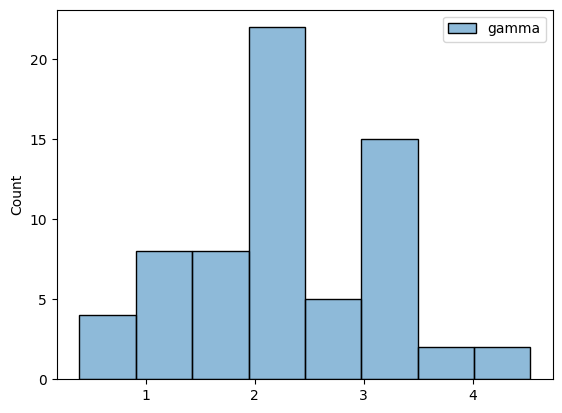

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

gamma_maps = pd.DataFrame(gamma.groupby('subject').mean().mean(axis=1), columns=['gamma'])
sns.histplot(gamma_maps)


In [15]:
subList_remove = [32,40,45,46,50]


In [4]:
model_label = 5
df['diff(risky-safe)'] = df['n_risky'] - df['n_safe']
df['x2'] = df['diff(risky-safe)'] 

format = 'symbolic'
data = df.xs(format, 0, level='format')
model = bambi.Model('chose_risky ~ x + x2 + (x + x2|subject)', link='probit', family='bernoulli', data=data.reset_index())

In [7]:
model_label = '5' #2 # '1rem1' #3  '2rem1' 
format ='symbolic' # 'symbolic' 

bids_folder = '/Users/mrenke/data/ds-dnumrisk'
target_folder = op.join(bids_folder, 'derivatives', 'cogmodels_risk')
traces = az.from_netcdf( op.join(target_folder, f'probit_model-{model_label}_format-{format}_trace.netcdf'))


In [8]:
traces.posterior.data_vars.keys()

KeysView(Data variables:
    Intercept         (chain, draw) float64 ...
    x                 (chain, draw) float64 ...
    x2                (chain, draw) float64 ...
    1|subject_sigma   (chain, draw) float64 ...
    x|subject_sigma   (chain, draw) float64 ...
    x2|subject_sigma  (chain, draw) float64 ...
    1|subject         (chain, draw, subject__factor_dim) float64 ...
    x|subject         (chain, draw, subject__factor_dim) float64 ...
    x2|subject        (chain, draw, subject__factor_dim) float64 ...)

In [27]:
tmp

x|subject
chain draw subject__factor_dim           
0     0    1                     1.623297
           2                    -1.090255
           3                    -2.387058
           4                    -1.039599
           5                    -0.470892
...                                   ...
3     999  62                    1.486189
           63                   -0.751777
           64                    0.512686
           65                   -0.653693
           66                    1.090095

[264000 rows x 1 columns]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


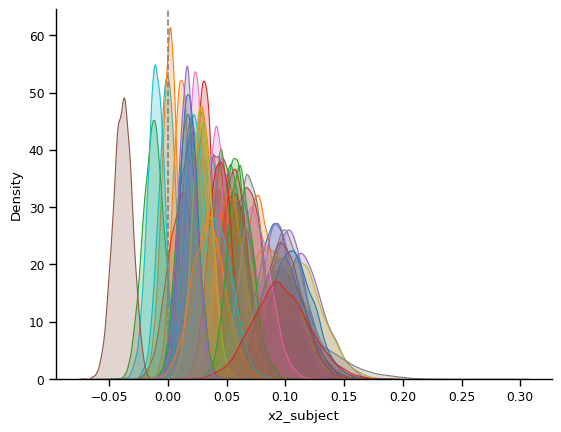

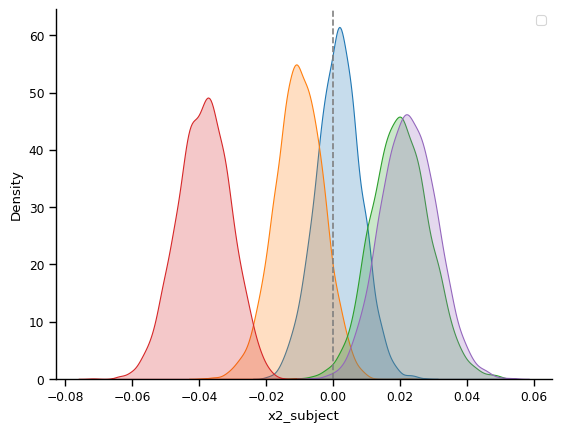

In [51]:
sns.set_context('paper')

var = 'x2_subject'
tmp = traces.posterior[['x2|subject', 'x2']].to_dataframe()
tmp[var] = tmp['x2|subject'] + tmp['x2']

for sub in range(1,66):#subList_remove:
    temp = tmp.xs(str(sub), level='subject__factor_dim')[var]
    count_greater_zero = np.round(np.mean(tmp[var] > 0),3)
    sns.kdeplot(temp, legend=False, fill=True)
plt.axvline(0, c='grey', ls='--')
sns.despine()

plt.figure()
for sub in subList_remove:
    temp = tmp.xs(str(sub), level='subject__factor_dim')[var]
    count_greater_zero = np.round(np.mean(tmp[var] > 0),3)
    sns.kdeplot(temp, fill=True)
plt.axvline(0, c='grey', ls='--')
plt.legend()
sns.despine()


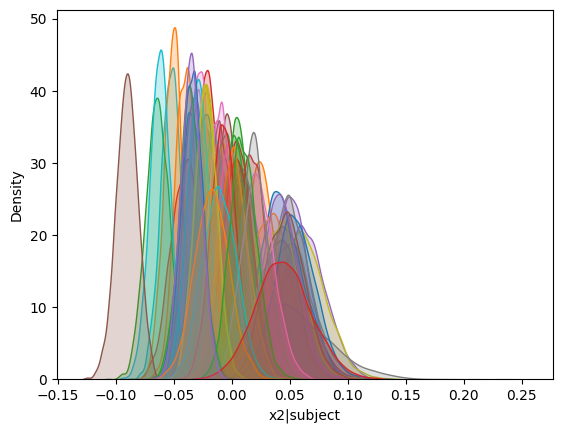

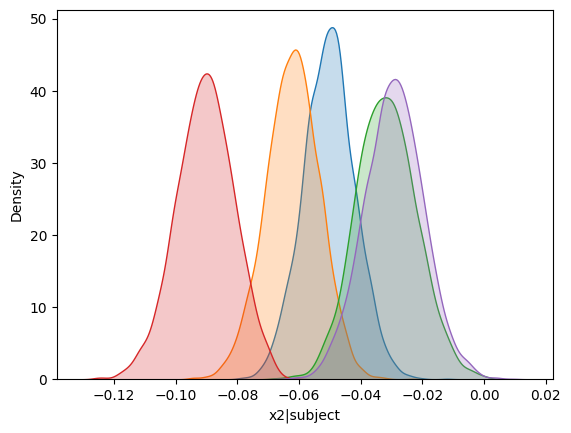

In [23]:
var = 'x2|subject'
tmp = traces.posterior[var].to_dataframe()

for sub in range(1,66):#subList_remove:
    temp = tmp.xs(str(sub), level='subject__factor_dim')[var]
    count_greater_zero = np.round(np.mean(tmp[var] > 0),3)
    sns.kdeplot(temp, legend=False, fill=True)

plt.figure()
for sub in subList_remove:
    temp = tmp.xs(str(sub), level='subject__factor_dim')[var]
    count_greater_zero = np.round(np.mean(tmp[var] > 0),3)
    sns.kdeplot(temp, legend=False, fill=True)



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


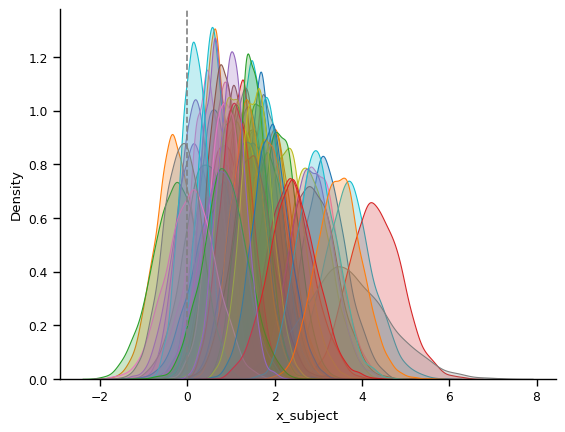

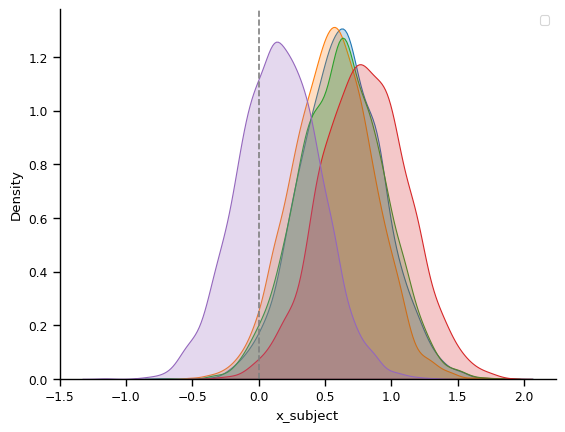

In [52]:
var = 'x_subject'
tmp = traces.posterior[['x|subject', 'x']].to_dataframe()
tmp[var] = tmp['x|subject'] + tmp['x']

for sub in range(1,66):#subList_remove:
    temp = tmp.xs(str(sub), level='subject__factor_dim')[var]
    count_greater_zero = np.round(np.mean(tmp[var] > 0),3)
    sns.kdeplot(temp, legend=False, fill=True)
plt.axvline(0, c='grey', ls='--')
sns.despine()

plt.figure()
for sub in subList_remove:
    temp = tmp.xs(str(sub), level='subject__factor_dim')[var]
    count_greater_zero = np.round(np.mean(tmp[var] > 0),3)
    sns.kdeplot(temp, fill=True)
plt.axvline(0, c='grey', ls='--')
plt.legend()
sns.despine()


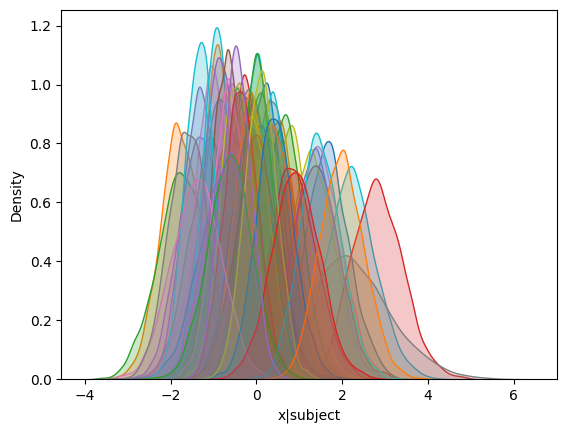

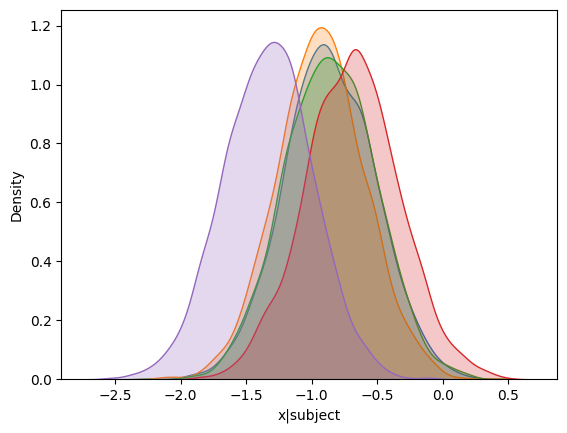

In [36]:
var = 'x|subject'
tmp = traces.posterior[var].to_dataframe()

for sub in range(1,66):#subList_remove:
    temp = tmp.xs(str(sub), level='subject__factor_dim')[var]
    count_greater_zero = np.round(np.mean(tmp[var] > 0),3)
    sns.kdeplot(temp, legend=False, fill=True)

plt.figure()
for sub in subList_remove:
    temp = tmp.xs(str(sub), level='subject__factor_dim')[var]
    count_greater_zero = np.round(np.mean(tmp[var] > 0),3)
    sns.kdeplot(temp, legend=False, fill=True)

